In [8]:
import pandas as pd
import numpy as np

import scipy.stats as stats #stats is used to access statistical function in python data analysis, hypothesis testing, probaility calculation, feature analysis

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #used to measure how accurate a classification model is.
from sklearn.model_selection import cross_val_score #used to perform Cross Validation, which helps you evaluate how well your model will perform on unseen data.

from sklearn.linear_model import LogisticRegression #It predicts the probability that an input belongs to a particular class.
from sklearn.tree import DecisionTreeClassifier #A Decision Tree makes predictions by asking a series of questions about the data.

from sklearn.preprocessing import FunctionTransformer #FunctionTransformer is used to apply your own custom function to data inside a Scikit-Learn pipeline.
from sklearn.compose import ColumnTransformer #ColumnTransformer is used when your dataset has different types of columns and you want to apply different preprocessing techniques to different columns.

In [12]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare','Survived']) # using only three columns 

In [13]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/var/folders/yq/qc_01rwd2js_mbwm5bxj2x_c0000gn/T/ipykernel_76989/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state =42)

/var/folders/yq/qc_01rwd2js_mbwm5bxj2x_c0000gn/T/ipykernel_76989/2584612803.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


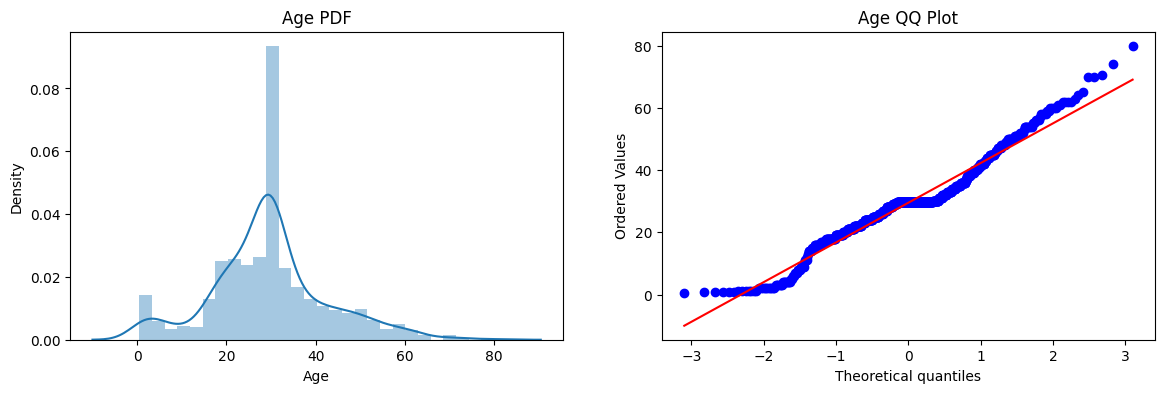

In [19]:
plt.figure(figsize=(14,4)) #size of the figure like height, width 
plt.subplot(121) # Subplot means dividing the figure into smaller sections. # 1row 2columns 1st graph
sns.distplot(X_train['Age']) # distplot() shows: 1. Histogram 2. Density Curve (KDE)
plt.title('Age PDF') #Probability Density Function

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot = plt)
plt.title('Age QQ Plot') #QQ = Quantile-Quantile Plot

plt.show()

/var/folders/yq/qc_01rwd2js_mbwm5bxj2x_c0000gn/T/ipykernel_76989/1642067668.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age']) # distplot() shows: 1. Histogram 2. Density Curve (KDE)


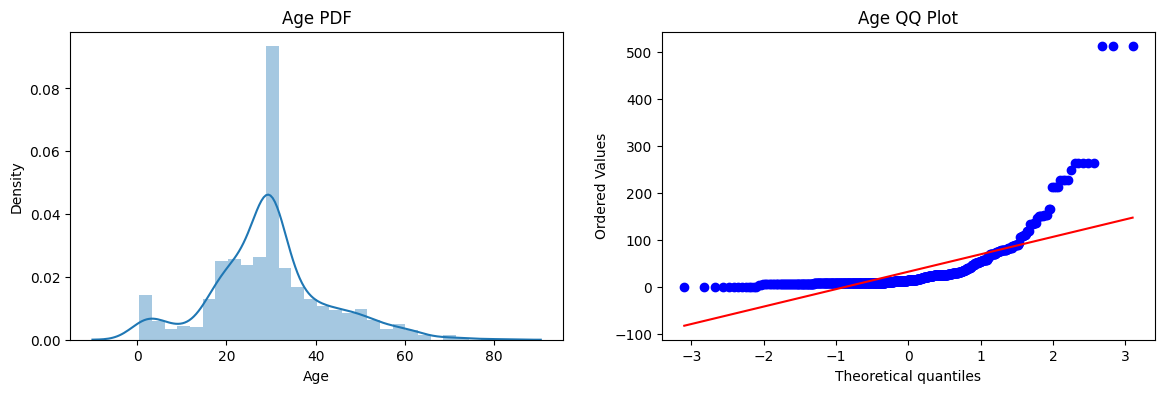

In [20]:
plt.figure(figsize=(14,4)) #size of the figure like height, width 
plt.subplot(121) # Subplot means dividing the figure into smaller sections. # 1row 2columns 1st graph
sns.distplot(X_train['Age']) # distplot() shows: 1. Histogram 2. Density Curve (KDE)
plt.title('Age PDF') #Probability Density Function

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot = plt)
plt.title('Age QQ Plot') #QQ = Quantile-Quantile Plot

plt.show()

In [24]:
c1f = LogisticRegression()
c1f2 = DecisionTreeClassifier()
# using oth the model for the accuracy at the same time

In [26]:
c1f.fit(X_train, y_train)
c1f2.fit(X_train,y_train)

y_pred = c1f.predict(X_test)
y_pred1 = c1f2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Acuuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Acuuracy DT 0.6815642458100558


In [31]:
trf = FunctionTransformer(func=np.log1p)
# trf = transformed                       

In [32]:
X_train_transformd = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [38]:
# Transform data first
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

# Train models
clf = LogisticRegression(max_iter=1000)
clf2 = DecisionTreeClassifier(random_state=42)

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

# Predict
y_pred_lr = clf.predict(X_test_transformed)
y_pred_dt = clf2.predict(X_test_transformed)

# Accuracy
print("Accuracy LR:", accuracy_score(y_test, y_pred_lr))
print("Accuracy DT:", accuracy_score(y_test, y_pred_dt))

Accuracy LR: 0.6815642458100558
Accuracy DT: 0.664804469273743


In [41]:
X_transformed = trf.fit_transform(X)

c1f = LogisticRegression()
c1f2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(c1f,X_transformed,y,scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(c1f2,X_transformed,y,scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6700624219725343


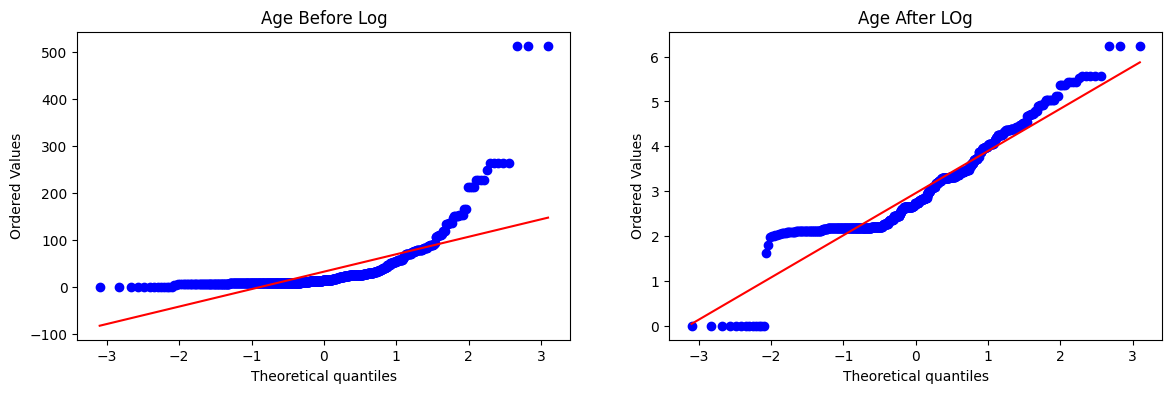

In [43]:
plt.figure(figsize=(14,4)) #size of the figure like height, width 
plt.subplot(121) # Subplot means dividing the figure into smaller sections. # 1row 2columns 1st graph
stats.probplot(X_train['Fare'], dist = "norm", plot= plt) # distplot() shows: 1. Histogram 2. Density Curve (KDE)
plt.title('Age Before Log') #Probability Density Function

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot = plt)
plt.title('Age After LOg') #QQ = Quantile-Quantile Plot

plt.show()

In [ ]:
# Decision tree does not care about who is the distribution of the data is 
# Other model care about the data distribution